In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv(r"C:\Users\yalla\OneDrive\Desktop\AICW vsm batch-2\ML Labs\End to end Wine Classification\winequality-red.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [5]:
data.drop_duplicates(inplace=True)
data.shape

(1359, 12)

In [6]:
data["quality"].unique()

array([5, 6, 7, 4, 8, 3])

In [7]:
data["quality"].value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

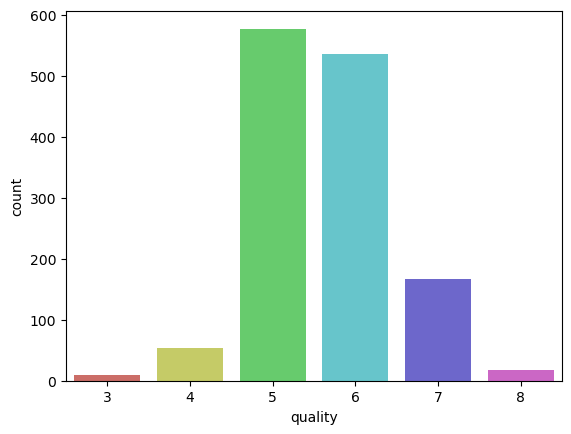

In [8]:
sns.countplot(x = data["quality"], palette = 'hls')
plt.show()

ovesampling ante ipudu naku 5th daniki graph ekva undi ante dhani rows ekuva(577) so dhani dagraki migilinavi anni techeyali 

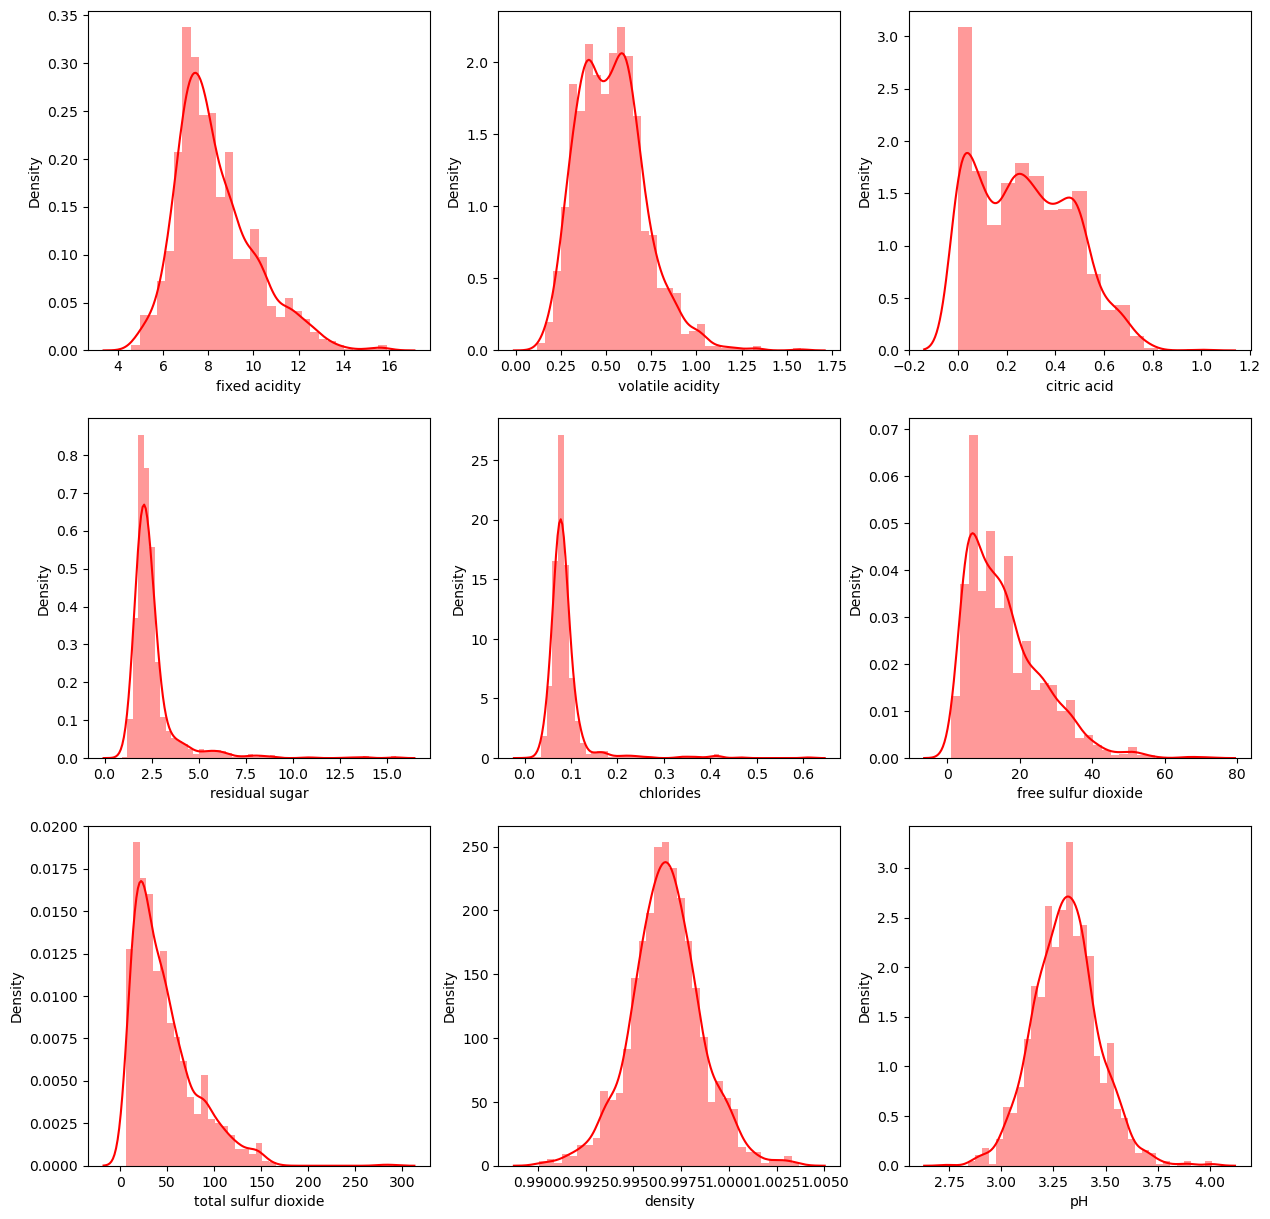

In [9]:
fig, ax = plt.subplots(3,3, figsize = (15,15))
sns.distplot(data["fixed acidity"], ax = ax[0,0],color = 'red')
sns.distplot(data["volatile acidity"], ax = ax[0,1], color = 'red')
sns.distplot(data["citric acid"], ax = ax[0,2], color = 'red')
sns.distplot(data["residual sugar"], ax = ax[1,0], color = 'red')
sns.distplot(data["chlorides"], ax = ax[1,1], color = 'red')
sns.distplot(data["free sulfur dioxide"], ax = ax[1,2], color = 'red')
sns.distplot(data["total sulfur dioxide"], ax = ax[2,0], color = 'red')
sns.distplot(data["density"], ax = ax[2,1], color = 'red')
sns.distplot(data["pH"], ax = ax[2,2], color = 'red')
plt.show()

In [10]:
#apply_log
data["residual sugar"] = np.log(data["residual sugar"])
data["chlorides"] = np.log(data["chlorides"])
data["free sulfur dioxide"] = np.log(data["free sulfur dioxide"])
data["total sulfur dioxide"] = np.log(data["total sulfur dioxide"])

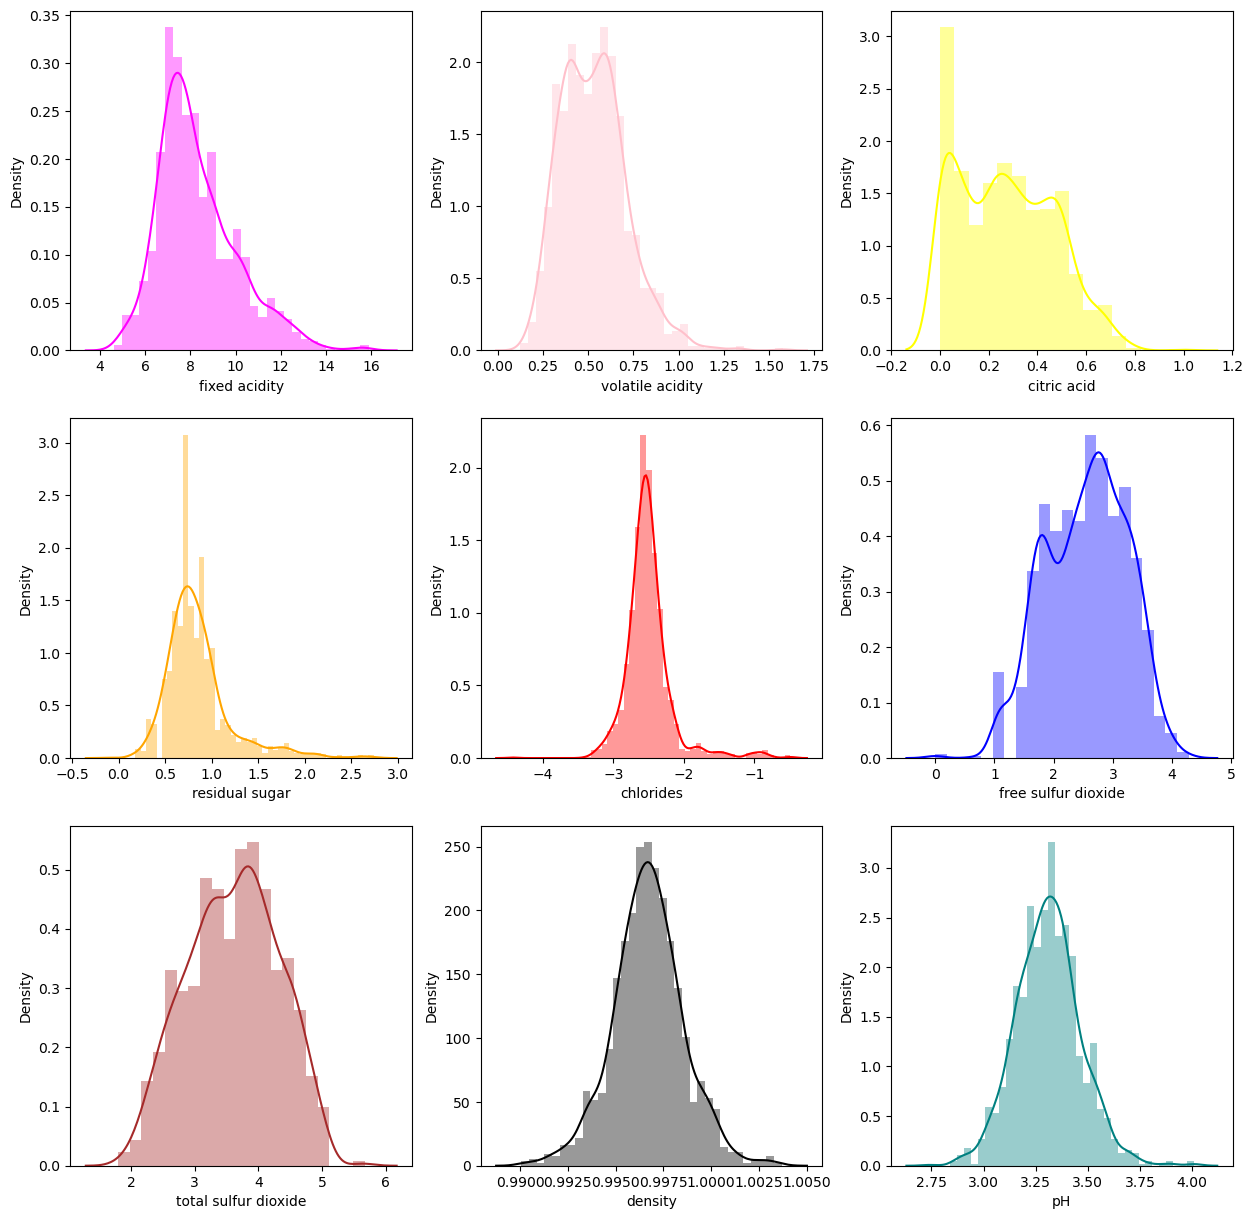

In [11]:
fig, ax = plt.subplots(3,3, figsize = (15,15))
sns.distplot(data["fixed acidity"], ax = ax[0,0],color = 'magenta')
sns.distplot(data["volatile acidity"], ax = ax[0,1], color = 'pink')
sns.distplot(data["citric acid"], ax = ax[0,2], color = 'yellow')
sns.distplot(data["residual sugar"], ax = ax[1,0], color = 'orange')
sns.distplot(data["chlorides"], ax = ax[1,1], color = 'red')
sns.distplot(data["free sulfur dioxide"], ax = ax[1,2], color = 'blue')
sns.distplot(data["total sulfur dioxide"], ax = ax[2,0], color = 'brown')
sns.distplot(data["density"], ax = ax[2,1], color = 'black')
sns.distplot(data["pH"], ax = ax[2,2], color = 'teal')
plt.show()

In [12]:
x = data.drop("quality", axis = 1)
x.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,0.641854,-2.577022,2.397895,3.526361,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,0.955511,-2.322788,3.218876,4.204693,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,0.832909,-2.385967,2.708050,3.988984,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,0.641854,-2.590267,2.833213,4.094345,0.9980,3.16,0.58,9.8
5,7.4,0.66,0.00,0.587787,-2.590267,2.564949,3.688879,0.9978,3.51,0.56,9.4


In [13]:
y = data["quality"]
y.head()

0    5
1    5
2    5
3    6
5    5
Name: quality, dtype: int64

In [14]:
from collections import Counter
from imblearn.over_sampling import SMOTE
print("Before:",Counter(y))
smote = SMOTE(random_state=42)
x_resampled,y_resampled = smote.fit_resample(x,y)
print("After:",Counter(y_resampled))

Before: Counter({5: 577, 6: 535, 7: 167, 4: 53, 8: 17, 3: 10})
After: Counter({5: 577, 6: 577, 7: 577, 4: 577, 8: 577, 3: 577})


In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_resampled,y_resampled,test_size=0.2)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((2769, 11), (693, 11), (2769,), (693,))

In [22]:
from sklearn.preprocessing import StandardScaler
Scalar=StandardScaler()
x_train=Scalar.fit_transform(x_train)
x_test=Scalar.transform(x_test)

In [23]:
x_train_data=pd.DataFrame(x_train,columns=x.columns)
x_train_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.170117,-1.151056,1.800046,-1.184690,-0.013522,0.607258,0.035202,-0.291443,-0.198224,0.811529,0.024254
1,-1.064298,0.434656,-0.479246,-0.902283,0.804555,-0.397017,-0.399682,-0.633563,0.633302,-1.374317,-1.221545
2,-0.289652,-0.588396,0.089266,0.390293,0.657797,0.786938,1.785234,0.093050,-0.724886,0.090551,-1.136605
3,2.174996,-0.642362,1.956995,0.792168,0.920796,-0.113978,-0.299022,1.900262,-1.177035,1.256507,-0.298675
4,-0.468955,-0.226686,-0.986081,0.276695,0.177303,0.947667,0.650059,0.039648,0.328437,-0.433796,-0.058665


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
LR_model=LogisticRegression()# model creation
LR_model.fit(x_train,y_train) #Train the model on training data
test_pred=LR_model.predict(x_test)# predictions on test data
LR_acc=accuracy_score(y_test,test_pred)
print(f"Log Reg model accuracy::{round(LR_acc*100)}")

Log Reg model accuracy::60


In [25]:
from sklearn.svm import SVC
SVC_model=SVC(kernel='linear')
SVC_model.fit(x_train,y_train)
test_pred=SVC_model.predict(x_test)
SVC_acc=accuracy_score(y_test,test_pred)
print(f"Support Vector Machine Model Accuracy::{round(SVC_acc*100)}")

Support Vector Machine Model Accuracy::62


In [26]:
from sklearn.tree import DecisionTreeClassifier
DT_model=DecisionTreeClassifier()
DT_model.fit(x_train,y_train)
test_pred=DT_model.predict(x_test)
DT_acc=accuracy_score(y_test,test_pred)
print(f"Decision tree accuracy::{round(DT_acc*100)}")

Decision tree accuracy::73


In [27]:
from sklearn.ensemble import RandomForestClassifier
RF_model=RandomForestClassifier()
RF_model.fit(x_train,y_train)
test_pred=RF_model.predict(x_test)
RF_acc=accuracy_score(y_test,test_pred)
print(f"Random forest accuracy::{round(RF_acc*100)}")

Random forest accuracy::82


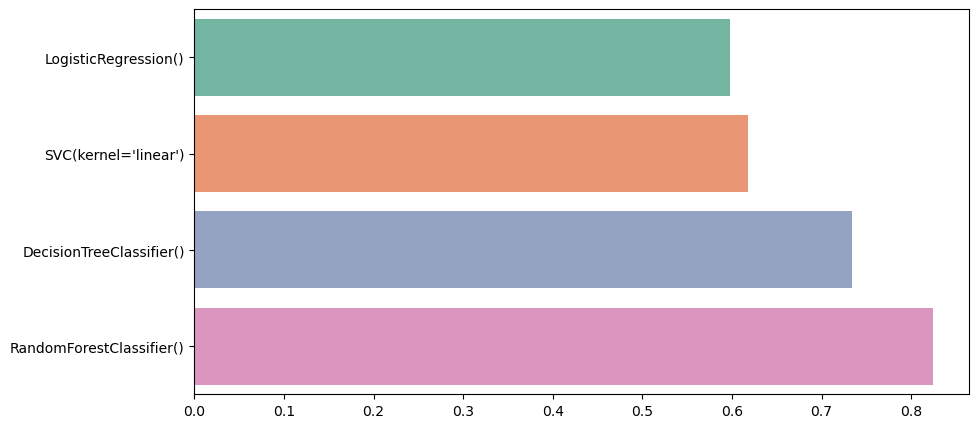

In [32]:
plt.figure(figsize=(10,5))

Models = [LR_model, SVC_model, DT_model, RF_model]
Acc = [LR_acc, SVC_acc, DT_acc, RF_acc]

sns.barplot(x=Acc, y=Models, palette="Set2")

plt.show()

In [35]:
import pickle
#save scalar parameters
filename = "New_scalar.pkl"
pickle.dump(Scalar,open(filename,"wb"))
#save model parameters 
filename = "New_RFmodel.pkl"
pickle.dump(RF_model,open(filename,"wb"))